###Exploring Dataset
The visual discrimination task described in the study is designed to test how well mice can distinguish between visual stimuli and make choices based on these stimuli. Here’s a breakdown of how the task is structured and what it aims to measure:

The study examines how mice make decisions based on visual stimuli by using a visual discrimination task. This task is designed to evaluate the mice's ability to differentiate between two visual patterns (gratings) and make choices based on their contrast. The task setup includes presenting these visual stimuli on screens, with the mice earning water rewards by correctly turning a wheel to indicate which grating has higher contrast. If no stimulus is presented, the mice should refrain from turning the wheel.

**Key Findings:**

**1-Neuronal Activity and Behavior:**

Neurons across various brain regions showed broad responses when the mouse initiated an action. However, specific neurons that encode visual stimuli and upcoming choices were localized in areas such as the neocortex, basal ganglia, and midbrain. Although choice signals were rare, they appeared simultaneously across these regions. The midbrain exhibited distinct activation patterns before different choices, while forebrain neurons preferred either side.

**2-Engagement and Task Performance:**

Pre-stimulus activity across the brain predicted the level of engagement in individual trials and overall task performance. Increased activity was observed in subcortical regions during engagement, whereas neocortical activity was suppressed.

**3-Task Design:**

The task required mice to earn rewards by turning a wheel based on the contrast of visual stimuli or by choosing not to turn if no stimulus was presented. The task incorporated a probability-based reward system based on the mice's choices.

**4-Dataset:**

The study involved 10 mice, across 39 sessions, resulting in 9,538 trials. Data collected included average task performance, reaction times, and choice probabilities based on stimulus contrasts.

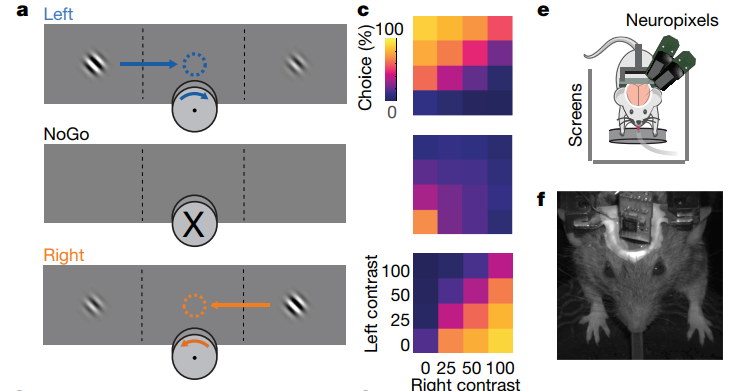



For the following code, I chose a day of recordings for one animal (Cori), the brain regions covered are:

Anterior cingulate area (ACA)

Field CA3 (CA3)

Dentate Gyrus (DG)

Lateral septal nucleus (LS)

Secondry motor area (MOs)

Subiculum (SUB)

Primary visual area (VISp)  

##CEBRA model

CEBRA is one of the most recent and promising neural encoding methods, it's a non-linear method that is both supervised (hypothesis-driven) and unsupervised (discovery-driven) to produce consistent latent space. It can produce a consistent latent space between different modalities (Neuropixels, calcium imaging, electrophysiology).

###Contrastive learning
CEBRA is an instant of nonlinear ICA and Contrastive Learning, the embeddings can be conditioned on auxillary variables (Behaviour) and/or time, the encoder (neural network) is trained with contrastive optimization objective function.

CEBRA optimizes neural networks \( f \) and \( f' \) to map neural activity data to an embedding space of a defined dimension. In this space, pairs of data samples \( (x, y) \) are compared using a similarity measure $\phi ( ⋅, \cdot )$.

### Notation and Optimization Criterion
1. **Embedding Function**: The neural networks $ f $ and $f' $ are functions that map input data samples \( x \) and \( y \) into an embedding space.
   
2. **Similarity Measure**: The function  ϕ measures the similarity between two data points in the embedding space.

3. **Auxiliary Function**: We use the notation $\psi(x, y) = \frac{\phi\left(f(x) , f'(y)\right))}{\tau} $, where $ \tau $ is a temperature hyperparameter that controls the sharpness of the similarity distribution.

4. **Optimization Criterion**: InfoNCE Loss, The optimization objective, known as the InfoNCE loss, is designed to maximize the similarity of positive pairs while minimizing the similarity of negative pairs. The criterion is given by:

$$
\mathbb{E}_{\substack{{\bf{x}} \sim p({\bf{x}}),\,{{\bf{y}}}_{+} \sim p({\bf{y}}|{\bf{x}}) \\ {{\bf{y}}}_{1},\ldots ,{{\bf{y}}}_{n} \sim q({\bf{y}}|{\bf{x}})}} \left[ -\psi({\bf{x}},{{\bf{y}}}_{+}) + \log \left(\sum_{i=1}^{n} \exp(\psi({\bf{x}},{{\bf{y}}}_{i}))\right) \right]
$$

This equation represents the expected value of the negative similarity score between a sample \( x \) and a positive sample \( y^+ \), plus the log-sum-exp of similarity scores between \( x \) and a set of negative samples \( y_i \). Here:

- $p(x) $: The distribution of input data.
-$p(y \mid x) $: The conditional distribution of positive pairs.
- $ q(y \mid x) $: The distribution from which negative samples are drawn.
- $ \psi(x, y) $: The similarity function between samples $ x $ and $ y $.
- $ E $: Denotes the expectation taken over the distributions of the data.


5. **Expectation and Summation**: The expectation $ \mathbb{E} $ is taken over positive pairs, while the summation runs over the negative samples in the batch.

### Intuitive Explanation

In essence, the method functions similarly to a classification problem: given a reference sample \( x \), the algorithm must identify the correct positive sample \(y^+\)from among many negative samples \( y_i^- \). This process helps in learning representations where similar samples are close in the embedding space, while dissimilar samples are pushed apart.

By optimizing this criterion, CEBRA aims to learn embeddings that capture the underlying structure of the data, thereby facilitating tasks like neural decoding.


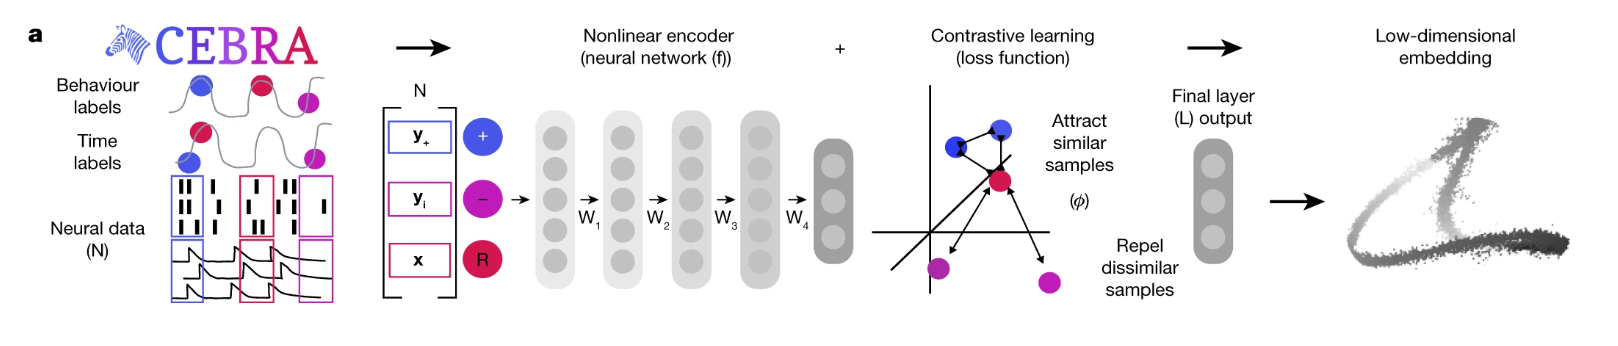

In [1]:
##in case cebra is not installed directly
"""
!pip uninstall -y torch cebra

# Install the desired version of PyTorch
# The command below assumes you want the latest version with CUDA 11.7 support
# Replace with 'cpu' if you do not need GPU support or adjust CUDA version accordingly
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# Now, install CEBRA
!pip install cebra
"""


Found existing installation: torch 2.4.0+cu121
ERROR: Operation cancelled by user
Looking in indexes: https://download.pytorch.org/whl/cu117
ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 kB 11.6 MB/s eta 0:00:00


In [ ]:
pip install cebra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 kB 5.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data can be found in this link:


In [ ]:
import numpy as np
import configparser

config = configparser.ConfigParser()
config.read('/content/drive/MyDrive/Colab Notebooks/config.ini') ##adjust the path to config.ini
default = config['DEFAULT']
data_path = default['DataPath']

neural_data = np.load(f"{data_path}firing_rates_Cori_2016-12-14.npz")['data']
behaviour_data = np.load(f"{data_path}behaviour_Cori_2016-12-14.npz")['data']


In [ ]:
neural_data_2 = np.load(f"{data_path}firing_rates_Cori_2016-12-17.npz")
neural_data_2 = neural_data_2['data']
behaviour_data_2 = np.load(f"{data_path}behaviour_Cori_2016-12-17.npz")
behaviour_data_2 = behaviour_data_2['data']

In [ ]:
print(neural_data.shape)
print(behaviour_data.shape)

(23025, 734)
(23025,)


Then we define Cebra model with many hyperparameters to set.

In [ ]:
import cebra
cebra_model = cebra.CEBRA(
  model_architecture = "offset10-model",
  batch_size = 32,
  temperature_mode = 'auto',
  learning_rate = 0.001,
  max_iterations = 5000,
  time_offsets = 10,
  conditional = 'time_delta',
  num_hidden_units = 64,
  output_dimension = 2,
  device = "cuda_if_available",
  verbose = True
)

### CEBRA Model Hyperparameters

- **`model_architecture`**: `"offset10-model"`
  - Specifies the architecture of the model. `"offset10-model"` is a predefined model architecture in CEBRA.

- **`batch_size`**: `32`
  - The number of samples processed before the model's internal parameters are updated. A batch size of 32 means the model will process 32 samples at a time.

- **`temperature_mode`**: `'auto'`
  - temperature is a hyperparameter that controls how "sharp" or "smooth" the similarity scores are. It essentially helps in scaling the logits (predictions before applying the softmax function) in models like contrastive learning or information retrieval. The 'auto' mode allows the model to adjust its optimal temprature value.

- **`learning_rate`**: `0.001`
  - The step size used by the optimizer to update the model's parameters during training. A learning rate of 0.001 determines how much to change the model parameters in response to the estimated error each time the model is updated.

- **`max_iterations`**: `5000`
  - The maximum number of iterations (or epochs) for training the model. The model will be trained up to 5000 iterations unless it converges earlier.

- **`time_offsets`**: `10`
  - Specifies the number of time offsets to be considered in the model. This parameter is relevant for models that deal with time-series data.

- **`conditional`**: `'time_delta'`
  - Defines the conditional structure of the model. `'time_delta'` suggests that the model's conditional dependencies are based on time differences between samples.

- **`num_hidden_units`**: `64`
  - The number of hidden units (neurons) in the hidden layers of the model. More hidden units can capture more complex patterns but may also lead to overfitting.

- **`output_dimension`**: `2`
  - The dimensionality of the output space of the model. An output dimension of 2 means the model will reduce the data to a 2-dimensional representation.

- **`device`**: `"cuda_if_available"`
  - Specifies the device to be used for training. `"cuda_if_available"` indicates that the model should use GPU acceleration if a compatible GPU is available; otherwise, it will fall back to the CPU.


 ### Methods and Analysis

To evaluate our model performance we use the reconstruction score, which is the $R^2$ score of linear regression between the resulting embedding and the behaviour labels, it represents how our embedding is able to retain the beaviour of the original neural recordings, we thought of this way because one of the applications of Neural Manifold learning is BCI where we can use a lower dimensional embedding of the data to understand command like left, right, up, and down so it will be great if we are able to achieve linear relationship between these two things.


In original CEBRA The authors were defining the reconstruction score as the $R^2$ score for linear regression between the embedding and the neural data, which represesnts how the embedding is able to reconstruct the original neural data using linear transformation.

Additionally, we thought of using the cross validation strategy to assess the robustness of the model

In [ ]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
def reconstruction_score(x, y):

    def _linear_fitting(x, y):
        lin_model = sklearn.linear_model.LinearRegression()
        lin_model.fit(x, y)
        return lin_model.score(x, y), lin_model.predict(x)

    return _linear_fitting(x, y)

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
def cross_val_score(neural_data, behaviour_data, model_class, cv=5):
    tscv = TimeSeriesSplit(n_splits=cv)

    # Initialize lists to store results
    train_reconstruction_scores = []
    val_reconstruction_scores = []
    fold_train_losses = []
    fold_val_losses = []

    for fold, (train_index, val_index) in enumerate(tscv.split(neural_data)):
        print(f"Fold {fold + 1}")

        # Split data into training and validation sets based on indices
        neural_train, neural_val = neural_data[train_index], neural_data[val_index]
        behaviour_train, behaviour_val = behaviour_data[train_index], behaviour_data[val_index]

        # Reinitialize model for each fold
        model = model_class

        # Train the model using the training data
        model.fit(neural_train, behaviour_train)

        # Compute training loss
        train_loss = cebra.sklearn.metrics.infonce_loss(model, neural_train, behaviour_train, num_batches=5)
        fold_train_losses.append(train_loss)

        # Compute validation loss
        val_loss = cebra.sklearn.metrics.infonce_loss(model, neural_val, behaviour_val, num_batches=5)
        fold_val_losses.append(val_loss)

        # Compute reconstruction score on validation data
        train_embedding = model.transform(neural_train)
        train_reconstruction, _ = reconstruction_score(train_embedding, behaviour_train)
        train_reconstruction_scores.append(train_reconstruction)
        val_embedding = model.transform(neural_val)
        val_reconstruction, _ = reconstruction_score(val_embedding, behaviour_val)
        val_reconstruction_scores.append(val_reconstruction)

    return fold_train_losses, fold_val_losses, train_reconstruction_scores, val_reconstruction_scores


In [ ]:
fold_train_losses , fold_val_losses, train_reconstruction_scores, val_reconstruction_scores = cross_val_score(neural_data, behaviour_data, cebra_model , 5)

Fold 1


pos: -3.6573 neg:  6.6459 total:  2.9886 temperature:  0.2733: 100%|██████████| 5000/5000 [01:04<00:00, 77.94it/s]
100%|██████████| 5/5 [00:00<00:00, 147.09it/s]


Fold 2


pos: -4.1947 neg:  6.9608 total:  2.7661 temperature:  0.2383: 100%|██████████| 5000/5000 [01:00<00:00, 82.32it/s]
100%|██████████| 5/5 [00:00<00:00, 268.75it/s]


Fold 3


pos: -3.5585 neg:  6.3830 total:  2.8246 temperature:  0.2803: 100%|██████████| 5000/5000 [00:59<00:00, 83.44it/s]
100%|██████████| 5/5 [00:00<00:00, 177.04it/s]


Fold 4


pos: -3.2089 neg:  6.1081 total:  2.8992 temperature:  0.2942: 100%|██████████| 5000/5000 [00:59<00:00, 83.76it/s]
100%|██████████| 5/5 [00:00<00:00, 262.72it/s]


Fold 5


pos: -1.0233 neg:  4.4890 total:  3.4657 temperature:  0.9772: 100%|██████████| 5000/5000 [00:59<00:00, 84.17it/s]
100%|██████████| 5/5 [00:00<00:00, 263.64it/s]


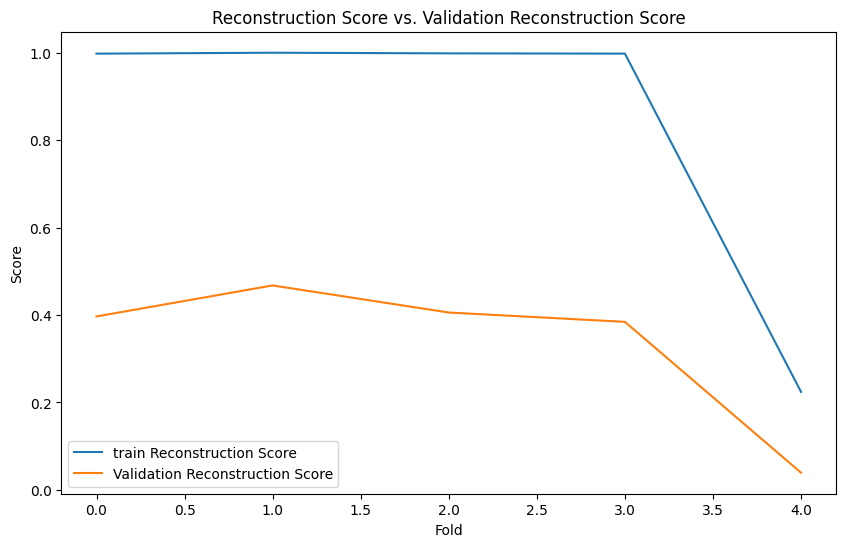

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_reconstruction_scores , label = 'train Reconstruction Score')
plt.plot(val_reconstruction_scores, label='Validation Reconstruction Score')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Reconstruction Score vs. Validation Reconstruction Score')
plt.legend()

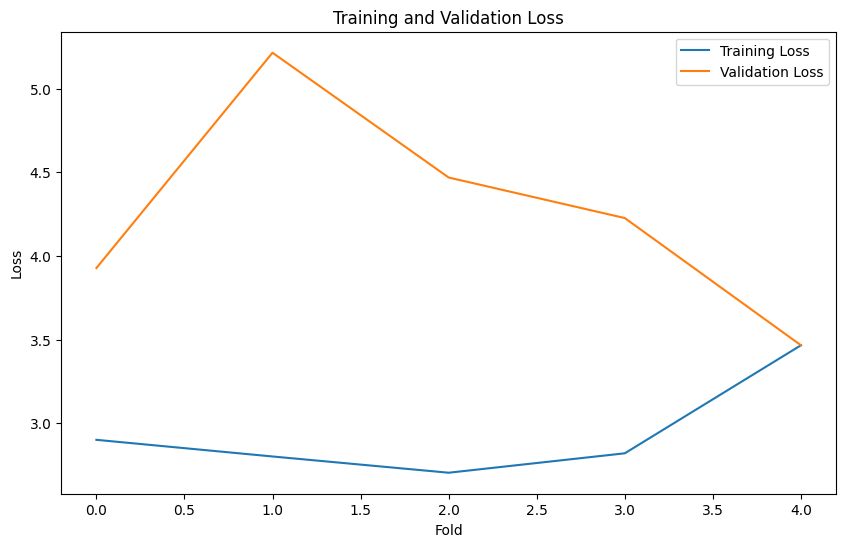

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(fold_train_losses, label='Training Loss')
plt.plot(fold_val_losses, label='Validation Loss')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
cebra_model.fit(neural_data, behaviour_data)

pos: -2.4443 neg:  5.2399 total:  2.7956 temperature:  0.4022: 100%|██████████| 5000/5000 [01:09<00:00, 72.10it/s]


CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

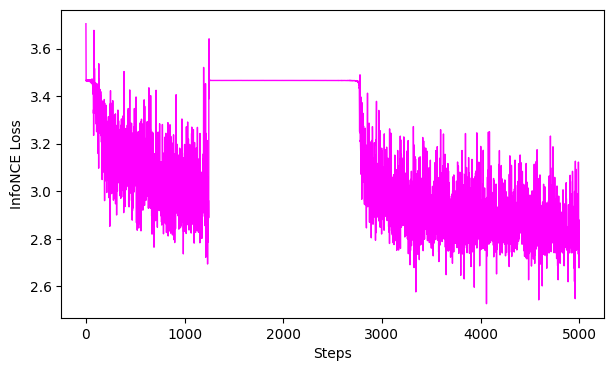

In [ ]:
cebra.plot_loss(cebra_model)


In [ ]:
embedding = cebra_model.transform(neural_data)

<Axes: title={'center': 'Embedding'}>

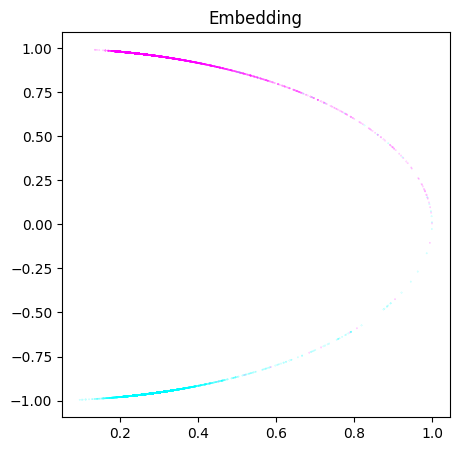

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding, embedding_labels=behaviour_data, idx_order=(0, 1))


I observed that the reconstruction score and loss are significantly worse during evaluation compared to training. This discrepancy might be due to overfitting caused by the high number of training iterations. To address this, we should consider reducing the number of iterations.

In [ ]:
import cebra
cebra_model_2 = cebra.CEBRA(
  model_architecture = "offset10-model",
  batch_size = 32,
  temperature_mode = 'auto',
  learning_rate = 0.001,
  max_iterations = 100,
  time_offsets = 10,
  conditional = 'time_delta',
  num_hidden_units = 128,
  output_dimension = 2,
  device = "cuda_if_available",
  verbose = True
)

In [ ]:
fold_train_losses , fold_val_losses, train_reconstruction_scores, val_reconstruction_scores = cross_val_score(neural_data, behaviour_data, cebra_model_2 , 5)

Fold 1


pos: -0.9530 neg:  4.0564 total:  3.1034 temperature:  0.9562: 100%|██████████| 100/100 [00:01<00:00, 62.73it/s]
100%|██████████| 5/5 [00:00<00:00, 221.36it/s]


Fold 2


pos: -0.7186 neg:  3.9127 total:  3.1941 temperature:  0.9467: 100%|██████████| 100/100 [00:02<00:00, 41.16it/s]
100%|██████████| 5/5 [00:00<00:00, 156.97it/s]


Fold 3


pos: -0.9911 neg:  4.4568 total:  3.4657 temperature:  1.0088: 100%|██████████| 100/100 [00:01<00:00, 72.39it/s]
100%|██████████| 5/5 [00:00<00:00, 187.58it/s]


Fold 4


pos: -0.7996 neg:  3.9347 total:  3.1351 temperature:  0.9751: 100%|██████████| 100/100 [00:01<00:00, 89.17it/s]
100%|██████████| 5/5 [00:00<00:00, 270.72it/s]


Fold 5


pos: -0.9026 neg:  4.0561 total:  3.1536 temperature:  0.9895: 100%|██████████| 100/100 [00:01<00:00, 86.49it/s]
100%|██████████| 5/5 [00:00<00:00, 267.61it/s]


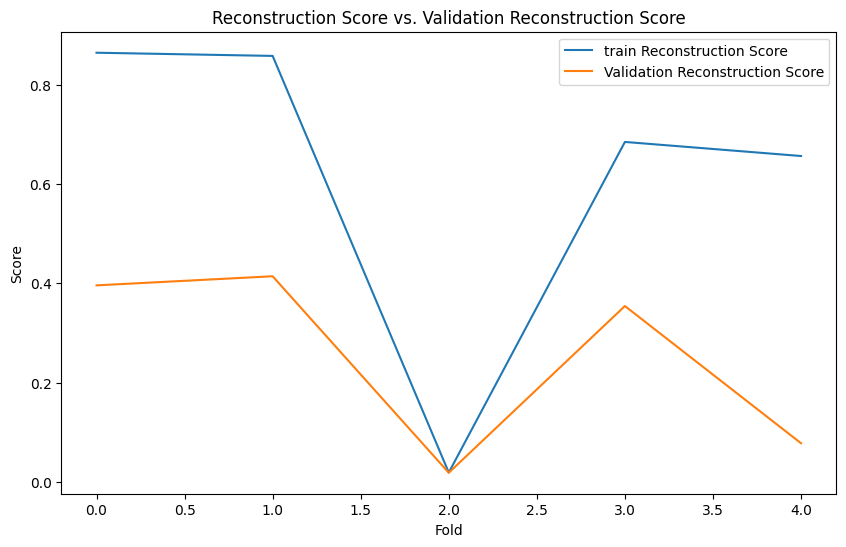

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_reconstruction_scores , label = 'train Reconstruction Score')
plt.plot(val_reconstruction_scores, label='Validation Reconstruction Score')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Reconstruction Score vs. Validation Reconstruction Score')
plt.legend()

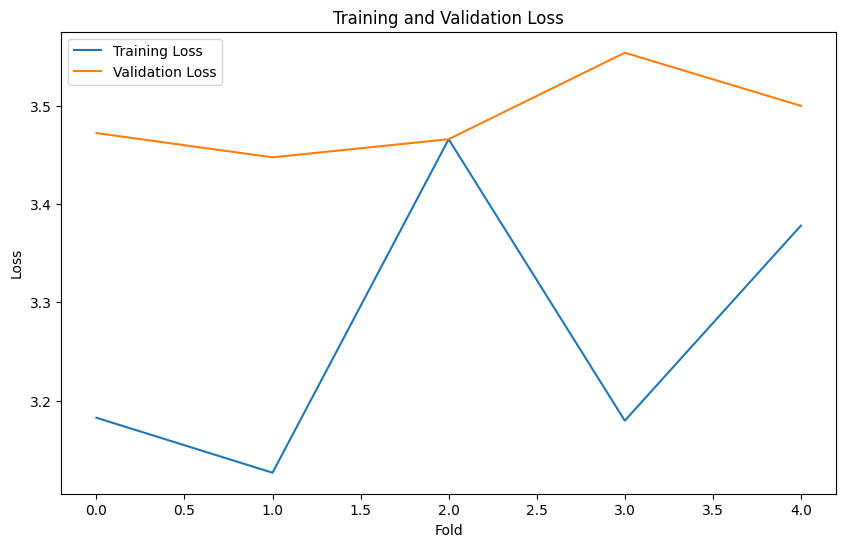

In [ ]:
# @title Default title text
plt.figure(figsize=(10, 6))
plt.plot(fold_train_losses, label='Training Loss')
plt.plot(fold_val_losses, label='Validation Loss')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

It is observed that with a high number of iterations (5000 in this case), the model tends to overfit, as evidenced by the large discrepancy between training loss and validation loss. Conversely, with fewer iterations (100), the training and validation losses are more similar. Therefore, finding a middle-ground number of iterations might improve performance

In [ ]:
cebra_model_3 = cebra.CEBRA(
  model_architecture = "offset10-model",
  batch_size = 32,
  temperature_mode = 'auto',
  learning_rate = 0.001,
  max_iterations = 100,
  time_offsets = 10,
  conditional = 'time_delta',
  num_hidden_units = 128,
  output_dimension = 2,
  device = "cuda_if_available",
  verbose = True
)

In [ ]:
fold_train_losses , fold_val_losses, train_reconstruction_scores, val_reconstruction_scores = cross_val_score(neural_data, behaviour_data, cebra_model_3 , 5)

Fold 1


pos: -2.0748 neg:  5.0890 total:  3.0141 temperature:  0.4741: 100%|██████████| 1000/1000 [00:12<00:00, 79.80it/s]
100%|██████████| 5/5 [00:00<00:00, 195.96it/s]


Fold 2


pos: -1.2776 neg:  4.5020 total:  3.2244 temperature:  0.5933: 100%|██████████| 1000/1000 [00:12<00:00, 77.86it/s]
100%|██████████| 5/5 [00:00<00:00, 106.43it/s]


Fold 3


pos: -1.0089 neg:  4.4742 total:  3.4653 temperature:  0.9902: 100%|██████████| 1000/1000 [00:12<00:00, 79.48it/s]
100%|██████████| 5/5 [00:00<00:00, 145.68it/s]


Fold 4


pos: -1.4037 neg:  4.3886 total:  2.9850 temperature:  0.6412: 100%|██████████| 1000/1000 [00:12<00:00, 79.18it/s]
100%|██████████| 5/5 [00:00<00:00, 189.25it/s]


Fold 5


pos: -1.0801 neg:  4.1624 total:  3.0823 temperature:  0.7663: 100%|██████████| 1000/1000 [00:13<00:00, 74.21it/s]
100%|██████████| 5/5 [00:00<00:00, 206.85it/s]


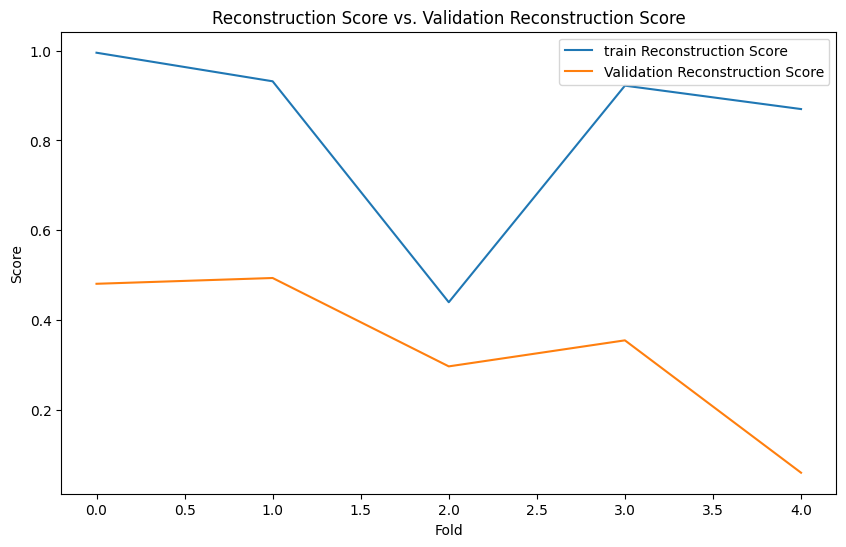

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_reconstruction_scores , label = 'train Reconstruction Score')
plt.plot(val_reconstruction_scores, label='Validation Reconstruction Score')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Reconstruction Score vs. Validation Reconstruction Score')
plt.legend()

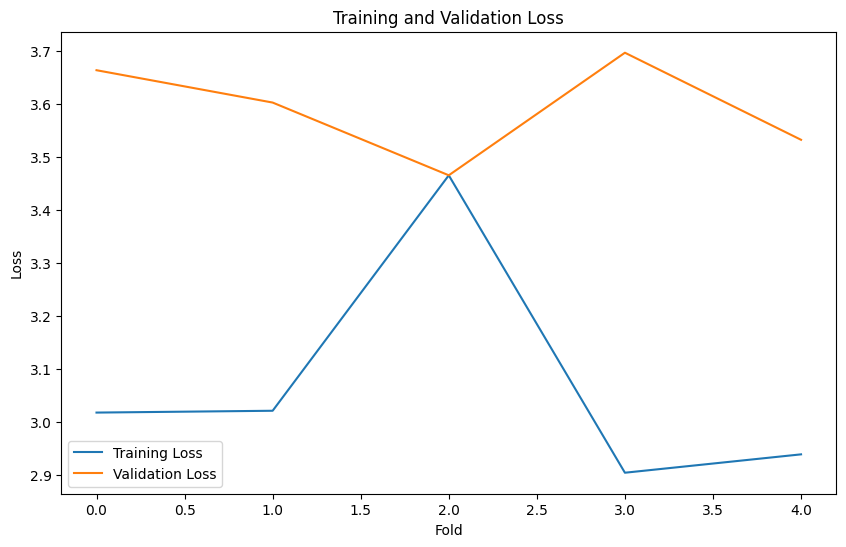

In [ ]:
# @title Default title text
plt.figure(figsize=(10, 6))
plt.plot(fold_train_losses, label='Training Loss')
plt.plot(fold_val_losses, label='Validation Loss')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
cebra_model_3.fit(neural_data, behaviour_data)

pos: -1.4187 neg:  4.2795 total:  2.8609 temperature:  0.6737: 100%|██████████| 1000/1000 [00:14<00:00, 70.78it/s]


CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=1000, model_architecture='offset10-model',
      num_hidden_units=128, output_dimension=2, temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

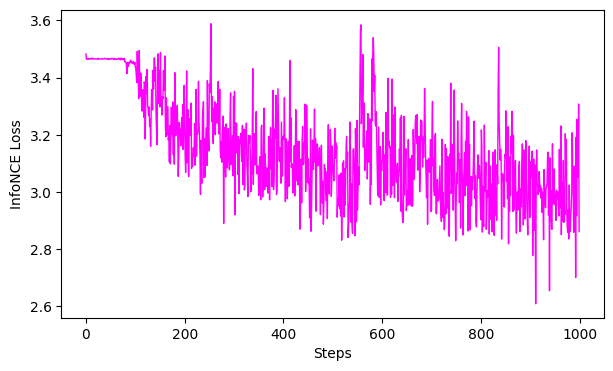

In [ ]:
cebra.plot_loss(cebra_model_3)


In [ ]:
embedding_3= cebra_model_3.transform(neural_data)

<Axes: title={'center': 'Embedding'}>

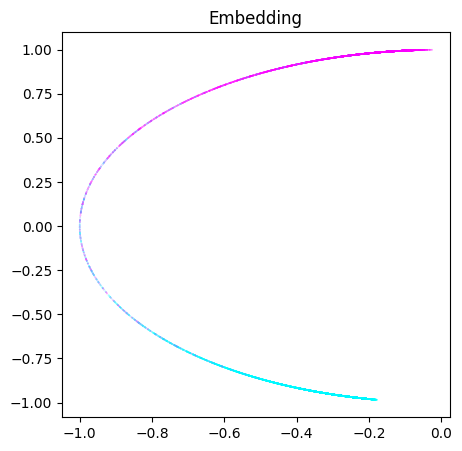

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding_3, embedding_labels=behaviour_data, idx_order=(0, 1))


In [ ]:
reconstruction, transformed_cebra_z  = reconstruction_score(embedding_3, behaviour_data)
print("Reconstruction score", reconstruction)

Reconstruction score 0.8885537347482564


Based on these observations, it seems that using 1000 iterations may strike a balance, potentially yielding reasonable embeddings with a good reconstruction score for behavior labels.

In [ ]:
## for neural data
reconstruction, transformed_cebra_z  = reconstruction_score(embedding_3, neural_data)
print("Reconstruction score", reconstruction)

Reconstruction score 0.01809200176065977


Let's try to see how model trained on 14-12 is able to transform the data from 17-12 into a meaningful embedding!!

In [ ]:
cebra_model_3.fit(neural_data_2, adapt = True) ##will just change the first input layer with the same weights

pos: -2.0105 neg:  4.3336 total:  2.3231 temperature:  0.4904: 100%|██████████| 500/500 [00:07<00:00, 70.20it/s]


CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=1000, model_architecture='offset10-model',
      num_hidden_units=128, output_dimension=2, temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

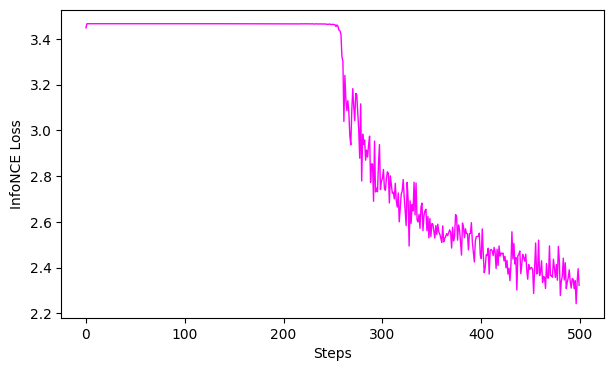

In [ ]:
cebra.plot_loss(cebra_model_3)


In [ ]:
embedding_2 = cebra_model_3.transform(neural_data_2)

<Axes: title={'center': 'Embedding'}>

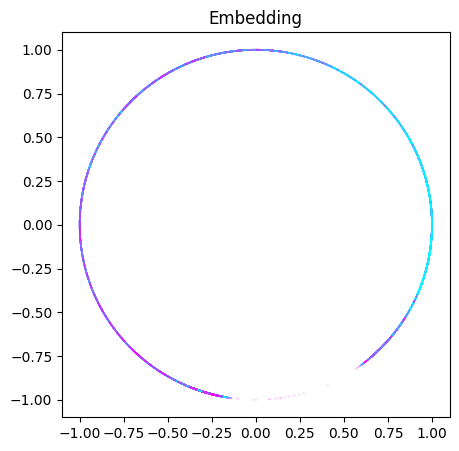

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding_2, embedding_labels=behaviour_data_2, idx_order=(0, 1))


In [ ]:
reconstruction, transformed_cebra_z  = reconstruction_score(embedding_2, behaviour_data_2)
print("Reconstruction score", reconstruction)

Reconstruction score 0.01706534902598167


Let's go back to 5000 iterations to see if it will make any difference!

In [ ]:
cebra_model.fit(neural_data, behaviour_data)

pos: -2.8351 neg:  5.7104 total:  2.8753 temperature:  0.3525: 100%|██████████| 5000/5000 [01:03<00:00, 79.08it/s]


CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

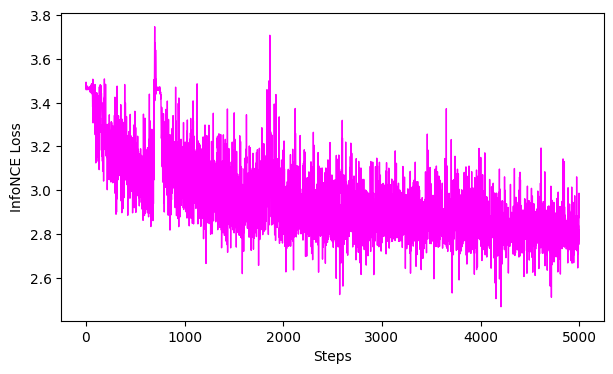

In [ ]:
cebra.plot_loss(cebra_model)

In [ ]:
embedding = cebra_model.transform(neural_data)

<Axes: title={'center': 'Embedding'}>

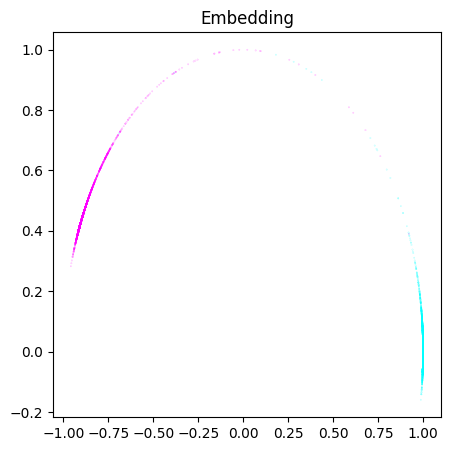

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding, embedding_labels=behaviour_data, idx_order=(0, 1))


In [ ]:
##Adaption to new data
cebra_model.fit(neural_data_2, adapt = True)

pos: -1.7541 neg:  4.4465 total:  2.6924 temperature:  0.5597: 100%|██████████| 500/500 [00:06<00:00, 80.13it/s]


CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10, verbose=True)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

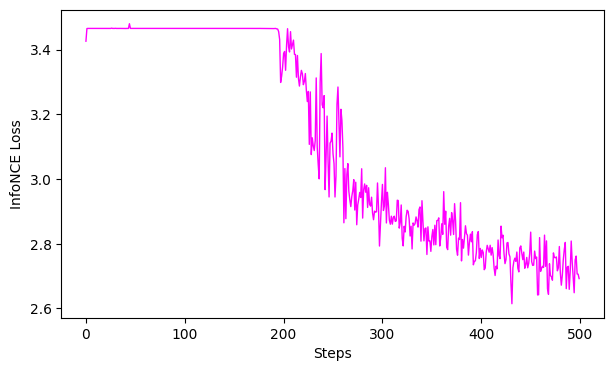

In [ ]:
cebra.plot_loss(cebra_model)


In [ ]:
embedding_2 = cebra_model.transform(neural_data_2)

<Axes: title={'center': 'Embedding'}>

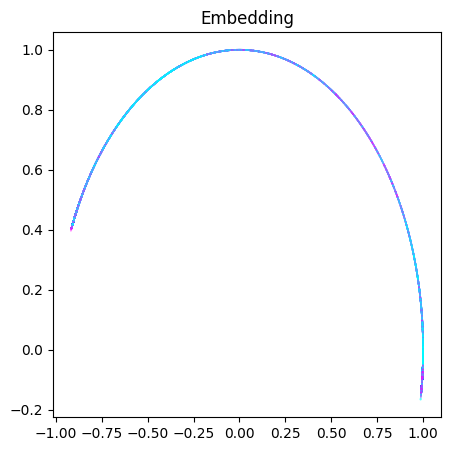

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding_2, embedding_labels=behaviour_data_2, idx_order=(0, 1))


In [ ]:
reconstruction, transformed_cebra_z  = reconstruction_score(embedding_2, behaviour_data_2)
print("Reconstruction score for Behaviour labels", reconstruction)

Reconstruction score for Behaviour labels 0.004645943753502801


##Two observations:##

1.   The embeddings are poorly separated, and the reconstruction score is significantly worse compared to the model trained with 100 iterations.

2. The current model is inadequate for retraining weights on new data, even with 5000 iterations. To address this, we will use the grid search function provided by CEBRA to explore potential improvements and identify a better model.









##Grid Search
CEBRA provides a function for grid serach through the hyperparameter trying different combinations of models.

In [ ]:
import cebra.models
models = print(cebra.models.get_options('offset*', limit = 4))


['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse']


In [ ]:
import cebra
import cebra.grid_search
params_grid = dict(
    model_architecture= ['offset10-model'],   # Fixed model architecture
    output_dimension=[2],  # Fixed output dimension
    learning_rate=[0.001, 0.01,0.0001],  # Example values, adjust as needed
    time_offsets=[1,5,10],  # Fixed time offsets
    max_iterations=[500],  # Fixed max iterations
    temperature_mode=['auto'],  # Temperature mode set to 'auto'
    batch_size=[32],
    conditional=['time_delta'],
    num_hidden_units=[64,128,32,256, 16],
    device=['cuda_if_available'],
    verbose=[False]
)

# Fit the models with the defined parameters
# Construct the input data
datasets = {"dataset1": (neural_data, behaviour_data)}

# Initialize and run the grid search
grid_search = cebra.grid_search.GridSearch()
grid_search.fit_models(datasets=datasets, params=params_grid, models_dir="saved_models")
# Retrieve the best model based on performance
best_model, best_model_name = grid_search.get_best_model()

print(f"Best Mode: {best_model}")
# Print the best model name and some details
print(f"Best Model Name: {best_model_name}")


Best Mode: CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=500, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10)
Best Model Name: learning_rate_0.001_num_hidden_units_64_time_offsets_10_dataset1


In [ ]:
best_model.fit(neural_data, behaviour_data)

CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=500, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

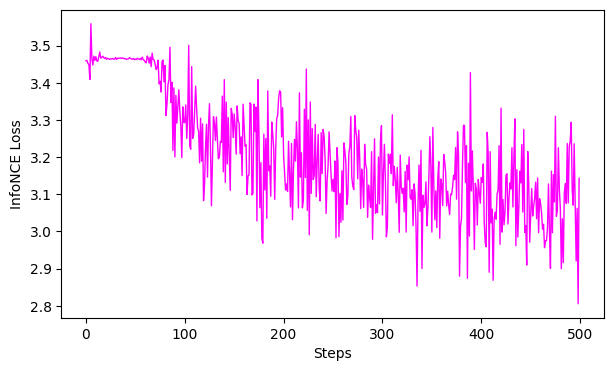

In [ ]:
cebra.plot_loss(best_model)

In [ ]:
embedding = best_model.transform(neural_data)

<Axes: title={'center': 'Embedding'}>

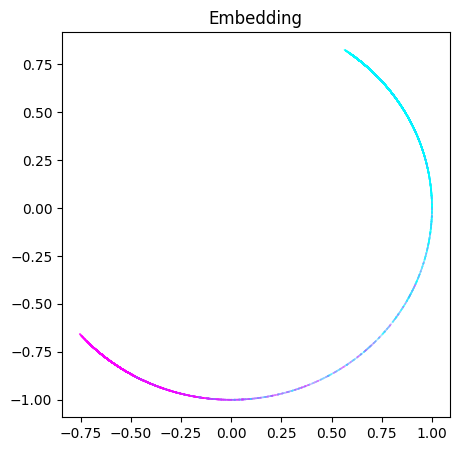

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding, embedding_labels=behaviour_data, idx_order=(0, 1))


In [ ]:
reconstruction_sc , _ = reconstruction_score(embedding, behaviour_data)
print("Reconstruction score for behaviour data", reconstruction_sc)

Reconstruction score for behaviour data 0.8339329790219752


In [ ]:
reconstruction_sc, _ = reconstruction_score(embedding, neural_data)
print("Reconstruction score for neural data", reconstruction_sc)

Reconstruction score for neural data 0.019424801289902614


"The same issue persists: the reconstruction score for the neural data is quite low, suggesting that the relationship between the embedding and the neural data may not be linear. This could be why linear network models struggle with data reconstruction.

To address this, we should consider the possibility of a nonlinear relationship. A single-layer neural network with a nonlinear activation function could better capture this complexity.

The MLP Regressor function in scikit-learn is well-suited for this task, as it can handle nonlinear relationships and provides an easily interpretable $R^2$ score."




In [ ]:
import sklearn
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

def MLP_reconstruction_score(x, y):

    def _mlp_fitting(x, y):
        # Create the MLPRegressor model with two hidden layers of 100 neurons each
        mlp_model = MLPRegressor(hidden_layer_sizes=(),activation = 'tanh', solver = 'lbfgs', max_iter=1000, learning_rate_init = 0.001)

        # Fit the model on the input data
        mlp_model.fit(x, y)

        # Return the R^2 score and the predictions
        return mlp_model.score(x, y), mlp_model.predict(x)

    return _mlp_fitting(x, y)


In [ ]:
reconstruction_sc, _ = MLP_reconstruction_score(embedding, neural_data)
print("Reconstruction score for neural data", reconstruction_sc)

Reconstruction score for neural data 0.008459761595689558


The same issue persists, indicating that there may be no direct connection between the embedding and the original data, which is concerning. Therefore, we should shift our focus to the behavior data. Specifically, we should investigate whether the embedding can be used to predict behavior in new data after adapting the model.

In [ ]:
best_model.fit(neural_data_2, adapt = True)

CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=500, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

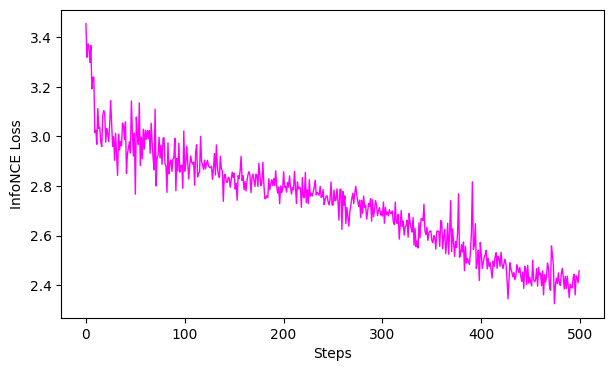

In [ ]:
cebra.plot_loss(best_model)

we notice the smooth training and low training error achieved by the model to new data!

In [ ]:
embedding_2 = best_model.transform(neural_data_2)

<Axes: title={'center': 'Embedding'}>

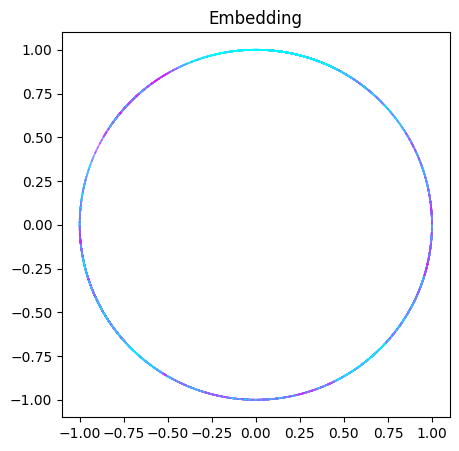

In [ ]:
cebra.integrations.matplotlib.plot_embedding(embedding_2, embedding_labels=behaviour_data_2, idx_order=(0, 1))


In [ ]:
behaviour_data_2.shape

(31744,)

<Axes: xlabel='Steps', ylabel='Temperature'>

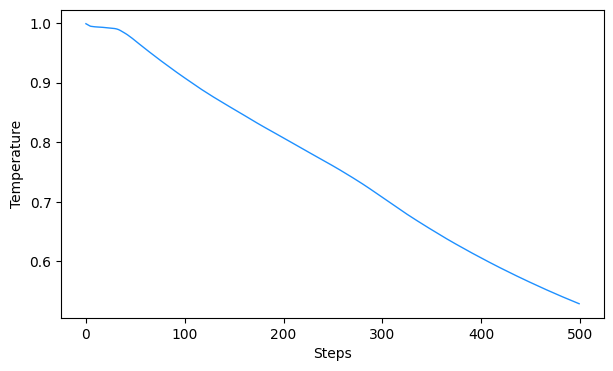

In [ ]:
cebra.integrations.matplotlib.plot_temperature(best_model)

In [ ]:
reconstruction_sc , _ = reconstruction_score(embedding_2, behaviour_data_2)
print("Reconstruction score for behaviour data", reconstruction_sc)

Reconstruction score for behaviour data 0.0057405174410034565


Despite the training loss decreasing effectively, the embeddings remain neither meaningful nor separable, and the reconstruction score for behavior is still too low. To address this, we have introduced a new metric to assess the separability of the model across the two classes. This metric calculates the separation score based on the similarity within each embedding class and the differences between the two classes.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
def separation_score(embedding, behaviour):
  embedding_0 = embedding[behaviour == 0]
  embedding_1 = embedding[behaviour == 1]

  # 2. Compute average similarity within each class
  similarity_0 = np.mean(cosine_similarity(embedding_0))
  similarity_1 = np.mean(cosine_similarity(embedding_1))

  # 3. Compute average similarity between classes
  between_similarity = np.mean(cosine_similarity(embedding_0, embedding_1))

  # 4. Print results
  print(f"Average similarity within class 0: {similarity_0:.4f}")
  print(f"Average similarity within class 1: {similarity_1:.4f}")
  print(f"Average similarity between classes: {between_similarity:.4f}")

  # 6. Optionally, you can compute a separation score
  separate_score = (similarity_0 + similarity_1) / 2 - between_similarity
  print(f"Separation score: {separate_score:.4f}")
  return separate_score



Let's try the best model obtained by the grid search

In [ ]:
score = separation_score(embedding, behaviour_data)

Average similarity within class 0: 0.7819
Average similarity within class 1: 0.8015
Average similarity between classes: -0.7038
Separation score: 1.4956


In [ ]:
## for adapted data
score = separation_score(embedding_2, behaviour_data_2)

Average similarity within class 0: 0.0020
Average similarity within class 1: 0.0153
Average similarity between classes: -0.0055
Separation score: 0.0141


We observe that the embeddings produced by the model during training exhibit a significantly better separation score compared to those from the adapted embedding.

##Discussion##


We conducted various analyses, including CEBRA-Behaviour (Supervised) with 5-fold cross-validation, CEBRA-Behaviour applied to the entire neural data, grid search for hyperparameter optimization, and model adaptation to new data.

It was not anticipated that we would achieve high reconstruction scores or low loss values for the validation set, as CEBRA is designed to produce a consistent latent space from previously seen neural data rather than predict unseen data. However, I expected CEBRA to achieve a high reconstruction score for the embedding and neural data, as demonstrated in the original publication with different examples. This discrepancy warrants further exploration if time permits, and may include using the row spiking data instead of converting it to firing rate, the problem with this was that CEBRA was able to deal with spiking in the opposite of BundleNet and PSID which need the data in a firing rate format

Additionally, I anticipated that adapting the model to a new dataset would yield more meaningful embeddings, but both visually and numerically, we did not achieve this outcome.

A critical next step is to integrate the results from CEBRA with the embeddings obtained from BundleNet and PSID. We will use the 5000 iterations model as it will have better seperation and reconstruction scores, in addition to better visualized embedding.

In [ ]:
import cebra
cebra_model_5000_iterations = cebra.CEBRA(
    model_architecture = "offset10-model",
    batch_size = 32,
    temperature_mode = 'auto',
    conditional='time_delta',
    learning_rate=0.001,
    max_iterations=5000,
    num_hidden_units=64,
    output_dimension=2,
    time_offsets=10)

In [ ]:
cebra_model_5000_iterations.fit(neural_data,behaviour_data)

CEBRA(batch_size=32, conditional='time_delta', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      num_hidden_units=64, output_dimension=2, temperature_mode='auto',
      time_offsets=10)

In [ ]:
CEBRA_embedding = cebra_model_5000_iterations.transform(neural_data)


In [ ]:
import numpy as np
PSID_embedding = np.load(f"{data_path}Cori_2016-12-14_PSID.npy")
Bundlenet_embedding = np.loadtxt(f"{data_path}Cori_2016-12-14_001_alf")


##First analysis: Weigthts values##

By performing a linear mapping between each embedding and the neural data, the values in the weights matrix can provide insights into which neurons or regions contribute most significantly to the weights.

The equation representing the relationship between the weights matrix, embeddings, and neural data can be expressed as:
$ \mathbf{W} \times \mathbf{E} = \mathbf{N} $

Where:
- $\mathbf{W}\$ represents the weights matrix,

- $\mathbf{E}\$ represents the embedding matrix,

- $\mathbf{N}\$ represents the neural data matrix.


What we will see know is encoding the neurons indicies as regions and plotting the weights values as heatmaps.

The problem of this calculation of weights that the embedding is an ill-conditioned matrix to be inverted, so we calculate the pseudo-inverse of the martrix

another thing is that the embedding of BundleNet is shorter than the other two embeddings due to the method itself, so we slice the other two embeddings to have equal time points.

In [ ]:
import pandas as pd

def convert_list_of_lists_to_array( list_of_lists):
        array = np.zeros((len(list_of_lists)))
        for i in range(len(list_of_lists)):
            array[i] = list_of_lists[i][0]
        return array

def load_brain_regions( path_prefix):

        br = pd.read_csv(f"{path_prefix}channels.brainLocation.tsv", sep='\t', header=None, names=['ccf_ap', 'ccf_dv', 'ccf_lr', 'brain_region'])

        phy_annotation = convert_list_of_lists_to_array(np.load(path_prefix + 'clusters._phy_annotation.npy')).astype(int)
        #cluster_probe = self.convert_list_of_lists_to_array(np.load(path_prefix + 'clusters.probes.npy')).astype(int)
        #channel_probe = self.convert_list_of_lists_to_array(np.load(path_prefix + 'channels.probe.npy')).astype(int)
        cluster_peakChannel = convert_list_of_lists_to_array(np.load(path_prefix + 'clusters.peakChannel.npy')).astype(int)

        indices = np.empty(0)

        for index, annotation in enumerate(phy_annotation):
            if annotation < 2.0:
                indices = np.append(indices, index)

        indices = indices.astype(int)

        cluster_peakChannel = np.delete(cluster_peakChannel, indices, 0)
        #cluster_probe = np.delete(cluster_probe, indices, 0)

        brain_region_list = [i for i in br.brain_region[1:]]

        cluster_brain_regions = {}

        for cluster, channel in enumerate(cluster_peakChannel):
            cluster_brain_regions[cluster] = brain_region_list[channel]

        return cluster_brain_regions


brain_regions = load_brain_regions(data_path)


In [ ]:
def calculate_weights(X, Y):
    X_pseudo_inverse = np.linalg.pinv(X)  # Compute the pseudoinverse of X
    W = np.dot(X_pseudo_inverse, Y)       # Calculate the transformation matrix W
    return W


Weights 1 shape : (734, 2)


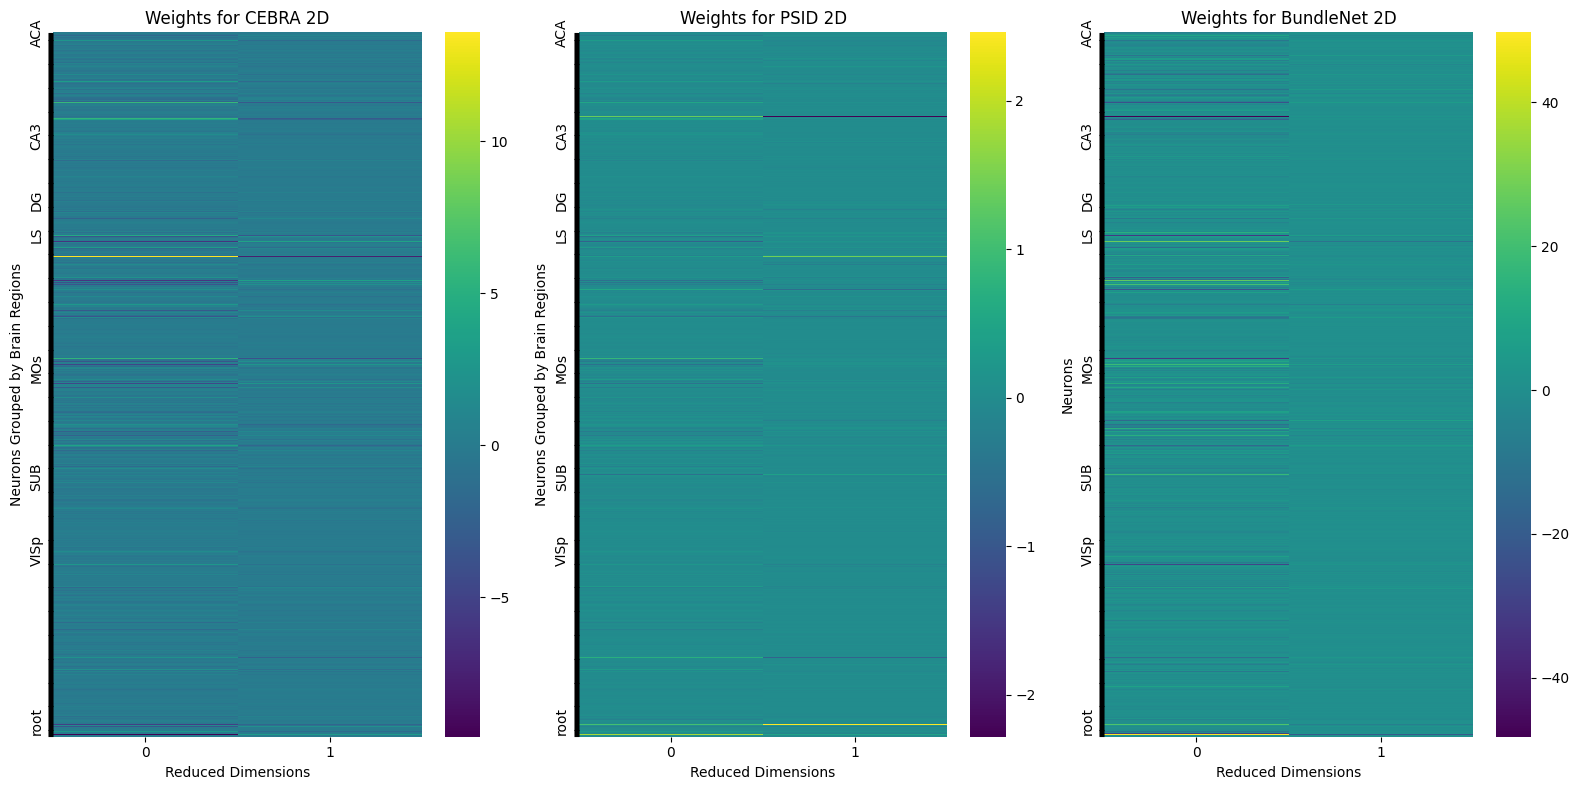

In [ ]:
embedding_cebra = CEBRA_embedding[:Bundlenet_embedding.shape[0], :]
embedding_PSID = PSID_embedding[:Bundlenet_embedding.shape[0], :]
neural = neural_data[:Bundlenet_embedding.shape[0], :]
import seaborn as sns
import matplotlib.pyplot as plt
weights_1 = calculate_weights(neural, embedding_cebra)
weights_2 = calculate_weights(neural, embedding_PSID)
weights_3 = calculate_weights(neural, Bundlenet_embedding)
print("Weights 1 shape :" , weights_1.shape)
sorted_indices = sorted(brain_regions.keys(), key=lambda x: brain_regions[x])
sorted_brain_regions = [brain_regions[i] for i in sorted_indices]
weights_1 = weights_1
weights_2 = weights_2
weights_3 = weights_3
sorted_weights_1 = weights_1[sorted_indices, :]
sorted_weights_2 = weights_2[sorted_indices, :]
sorted_weights_3 = weights_3[sorted_indices, :]
# Create labels for the y-axis based on brain regions, but only display the region name once per group
y_labels = []
current_region = ""
for region in sorted_brain_regions:
    if region != current_region:
        y_labels.append(region)
        current_region = region
    else:
        y_labels.append("")  # Leave empty to avoid repeating region names

# Plotting the heatmaps
plt.figure(figsize=(16, 8))

# Heatmap for weights of embedding 1
plt.subplot(1, 3, 1)
sns.heatmap(sorted_weights_1, cmap='viridis', cbar=True, yticklabels=y_labels)
plt.title("Weights for CEBRA 2D")
plt.xlabel("Reduced Dimensions")
plt.ylabel("Neurons Grouped by Brain Regions")

# Heatmap for weights of embedding 2
plt.subplot(1, 3, 2)
sns.heatmap(sorted_weights_2, cmap='viridis', cbar=True, yticklabels=y_labels)
plt.title("Weights for PSID 2D")
plt.xlabel("Reduced Dimensions")
plt.ylabel("Neurons Grouped by Brain Regions")

plt.subplot(1, 3, 3)
sns.heatmap(sorted_weights_3, cmap='viridis', yticklabels=y_labels, cbar=True)
plt.title("Weights for BundleNet 2D")
plt.xlabel("Reduced Dimensions")
plt.ylabel("Neurons")

plt.tight_layout()
plt.show()


It can be obviously seen that certain neurons in certain regions have common representation, either by high values of weights or low values of weights.

##Second Analysis: Dynamic Similarity Analysis (DSA): ##

DSA is a method desigend compare the dynamics of two neural systems. It integrates concepts from Statistical Shape Analysis and Dynamical Systems Theory.

the nonlinear dynamic is embedded into a linear space using **Koopman operator**

**Dynamic Mode Decomposition** is used to define linear transition operator within this space, a modified Procrustes Analysis is applied to compare the resulting DMD matrices providing a measure of similarity.

**Multidimensional Scaling (MDS)** is a statistical technique used for dimensionality reduction. It aims to represent high-dimensional data in a lower-dimensional space, typically 2D or 3D, while preserving the distances or dissimilarities between data points as much as possible. The primary goal of MDS is to visualize the similarity or dissimilarity between objects in a dataset.

MDS takes a matrix of pairwise distances or dissimilarities between objects as input, then it produces a lower-dimensional representation (usually 2D or 3D) of the data where the distance between points reflects their original dissimilarity.

To provide a good comparison we will show 5 different embeddings:


1.   Cori 14-12 CEBRA
2.   Cori 14-12 BundleNet
3.   Cori 14-12 PSID
4.   Cori 17-12 CEBRA
5.   Cori 18-12 CEBRA

We want to see more similarity between the 3 embeddings from the same day than the other 2. Note that 17-12 has totally different recording regions same goes for 18-12.





In [ ]:
!git clone https://github.com/mitchellostrow/DSA


Cloning into 'DSA'...
remote: Enumerating objects: 340, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 340 (delta 16), reused 24 (delta 14), pack-reused 304 (from 1)
Receiving objects: 100% (340/340), 1.52 MiB | 20.19 MiB/s, done.
Resolving deltas: 100% (189/189), done.


In [ ]:
%cd DSA/
!pip install .


/content/DSA
Processing /content/DSA
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 26.3 MB/s eta 0:00:00
  Created wheel for DSA: filename=DSA-1.0.1-py3-none-any.whl size=18638 sha256=61258f2a3378c774c85d3332d754ed2a1bfa84af2ba63117687905901fed0f5f
  Stored in directory: /tmp/pip-ephem-wheel-cache-y3j5iivk/wheels/e9/84/01/b2f96dc3af27415aa184a4a0f6bda9ee0026334ab3fb046f3a
Successfully built DSA


In [ ]:
pip install omegaconf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144554 sha256=8e0838c1a0bc427e4ae844f27e2d630c6e2b7aa112ed0a69fdb65785d3615b6c
  Stored in directory: /root/.cache/pip/wheels/12/93/dd/1f6a127edc45659556564c5730f6d4e300888f4bca2d4c5a88
Successfully built antlr4-python3-runtime


In [ ]:
## Load data
Cori_1712_cebra = np.load(f"{data_path}CEBRA_embedding_17-12_10000_iterations.npz")
Cori_1712_cebra = Cori_1712_cebra['data']

Cori_1812_cebra = np.load(f"{data_path}CEBRA_embedding_18-12_10000_iterations.npz")
Cori_1812_cebra = Cori_1812_cebra['data']





In [ ]:
all_embeddings = [CEBRA_embedding , Bundlenet_embedding , PSID_embedding, Cori_1712_cebra, Cori_1812_cebra ]
all_models = ["CEBRA Cori 14-12" , "BundlNet Cori 14-12" , "PSID Cori 14-12" , "CEBRA Cori 17-12" , "CEBRA Cori 18-12"  ]

The original code uses cuda for the computations but this was not avaiable on colab.

In [ ]:
from DSA.dmd import DMD
from DSA.simdist import SimilarityTransformDist
from sklearn.manifold import MDS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def fit_dmd(x,n_delays,rank,delay_interval):
    dmd = DMD(x,n_delays=n_delays,rank=rank,delay_interval=delay_interval, send_to_cpu=True)
    dmd.fit()
    return dmd.A_v.numpy()


def DMD_analysis(embeddings, names):
  """
  embeddings : list of embeddings from different models

  names: list of modles' names for plotting purposes

  """
  nmodels = 5
  n_delays = 2
  delay_interval = 8
  rank = 40
  downsample = 1

  models = []
  for i in range(nmodels):
    dmd = fit_dmd(embeddings[i],n_delays,rank,downsample)
    models.append(dmd)


  nmodels_tot = len(models)
  sims_dmd = np.zeros((nmodels_tot,nmodels_tot))
  sims_mtype = np.zeros((nmodels_tot,nmodels_tot))
  comparison_dmd = SimilarityTransformDist(iters=2000,lr=1e-2)

  for i,mi in enumerate(models):
      for j,mj in enumerate(models):
          smtype = int(names[i] == names[j])
          sims_mtype[i,j] = sims_mtype[j,i] = smtype
          if i == j:
              sims_mtype[i,i] = 2
          if j < i:
              continue
          sdmd = comparison_dmd.fit_score(mi,mj)
          print(names[i],names[j],"similarity is ", sdmd)

          sims_dmd[i,j] = sims_dmd[j,i] = sdmd

  df = pd.DataFrame()
  df['Model Type'] = names
  lowd_embedding = MDS(dissimilarity='precomputed').fit_transform(sims_dmd)
  df[f"DMD:0"] = lowd_embedding[:,0]
  df[f"DMD:1"] = lowd_embedding[:,1]


  fig,ax = plt.subplots(1,1,sharex=True,sharey=True)
  palette = 'husl'
  sns.scatterplot(data=df,x=f"DMD:0",y=f"DMD:1",hue="Model Type",ax=ax,palette=palette)
  ax.set_xlabel(f"MDS 1")
  ax.set_ylabel(f"MDS 2")
  plt.tight_layout()
  plt.show()


CEBRA Cori 14-12 CEBRA Cori 14-12 similarity is  0
CEBRA Cori 14-12 BundlNet Cori 14-12 similarity is  0.6109738
CEBRA Cori 14-12 PSID Cori 14-12 similarity is  0.6683681
CEBRA Cori 14-12 CEBRA Cori 17-12 similarity is  0.059583127
CEBRA Cori 14-12 CEBRA Cori 18-12 similarity is  0.26409006
BundlNet Cori 14-12 BundlNet Cori 14-12 similarity is  0.0
BundlNet Cori 14-12 PSID Cori 14-12 similarity is  0.15986578
BundlNet Cori 14-12 CEBRA Cori 17-12 similarity is  0.6149681
BundlNet Cori 14-12 CEBRA Cori 18-12 similarity is  0.6183684
PSID Cori 14-12 PSID Cori 14-12 similarity is  0.0
PSID Cori 14-12 CEBRA Cori 17-12 similarity is  0.67429847
PSID Cori 14-12 CEBRA Cori 18-12 similarity is  0.6645358
CEBRA Cori 17-12 CEBRA Cori 17-12 similarity is  0.0
CEBRA Cori 17-12 CEBRA Cori 18-12 similarity is  0.3039511
CEBRA Cori 18-12 CEBRA Cori 18-12 similarity is  0.00034526698


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


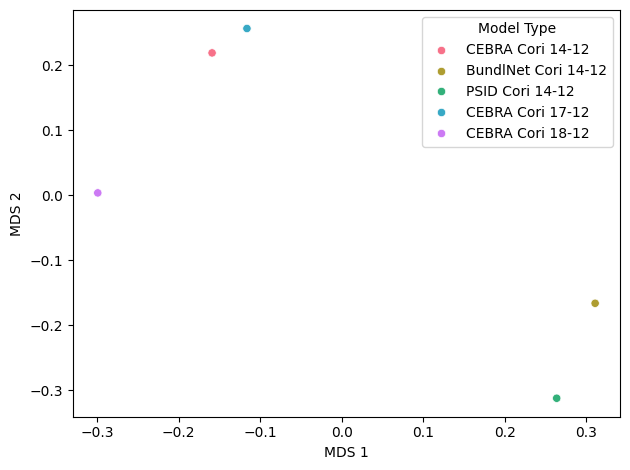

In [ ]:
DMD_analysis(all_embeddings , all_models)

After trying different combinations of ndelays which refers to the number of time delays (or past time steps) that are used to create the delay-embedded version of the data. and delay_interval which refers to the time interval between consecutive delays used in the delay embedding,  we found that in most cases the similarity between the CEBRA models dyamics even on different regions is higher than the other two embeddings, and we can find high similarity between the BundNet and PSID embeddings.

## Conclusion

In this report, we performed so many analyses in different phases of the project, first one is to optimize CEBRA model outcome and quality of the embedding using Cross Validation strategy, grid search, and evaluation metrics like reconstruction score and separation score. One take in this context is the use of reconstruction score, we found that the definition of reconstruction score in original CEBRA which is $R^2$ between embedding and neural data is not applicable in our case as the value is too low. It may be due to the preprocessing and the nature of the data is it's firing rate for spiking data, for LFP or direct spiking data.


Second analysis is to look for the weights that map the embedding to neural data, this resulted into meaningful and common neurons and regions of interest across the 3 Methods (CEBRA, BundleNet, PSID).

Third analysis we saw is using DSA to compare between the 5 embeddings, 3 of the same day and 2 from 2 other days. DSA resulted that the dynamics generated by CEBRA in the 3 different days are closer to each other than the other 2 Models.
